# Y 분포 비교 (train / validation / test)

`compet_ys_train_data.csv`, `compet_ys_validation_data.csv`, `compet_ys_test_data.csv` 세 split의 `health` 분포가 서로 일치하는지 확인하는 간단한 체크 노트북.

In [1]:
import os, sys

try:
    import google.colab
    if not os.path.exists("/content/project/setup.py"):
        os.system("pip install -q gdown")
        os.system("gdown --id 1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I -O /content/code.zip")
        os.system("unzip -qo /content/code.zip -d /content/project")
        os.makedirs("/content/project/0_data", exist_ok=True)
        os.system("gdown --id 1yOUo0_wPLcuZBSJIK592b00YkSIlk4zO -O /content/project/0_data/dataset.zip")
        os.system("unzip -qo /content/project/0_data/dataset.zip -d /content/project/0_data")
        os.remove("/content/project/0_data/dataset.zip")
    sys.path.insert(0, "/content/project")
    %run /content/project/setup.py
except ImportError:
    %run ../setup.py

setup 완료


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.config import TARGET_COL
from utils.data import load_ys

ys = load_ys()
splits = ["train", "validation", "test"]
for s in splits:
    print(f"{s:10s}: {ys[s].shape}")

train     : (26247, 2)
validation: (8749, 2)
test      : (8749, 2)


## 1. 기본 통계 비교

In [3]:
rows = []
for s in splits:
    y = ys[s][TARGET_COL]
    rows.append({
        "split": s,
        "n": len(y),
        "zero_ratio": (y == 0).mean(),
        "mean": y.mean(),
        "std": y.std(),
        "min": y.min(),
        "q25": y.quantile(0.25),
        "median": y.median(),
        "q75": y.quantile(0.75),
        "q99": y.quantile(0.99),
        "max": y.max(),
    })

stats = pd.DataFrame(rows).set_index("split")
stats.round(6)

,n,zero_ratio,mean,std,min,q25,median,q75,q99,max
split,,,,,,,,,,
train,26247,0.708005,0.002515,0.008301,0.0,0.0,0.0,0.002257,0.024243,1.000000
validation,8749,0.707967,0.002505,0.005815,0.0,0.0,0.0,0.002348,0.023806,0.172211
test,8749,0.707967,0.002610,0.008494,0.0,0.0,0.0,0.002309,0.025029,0.602242


## 2. Y > 0 만의 분포 (zero-inflated 제외)

In [4]:
rows = []
for s in splits:
    y = ys[s][TARGET_COL]
    y_pos = y[y > 0]
    rows.append({
        "split": s,
        "n_pos": len(y_pos),
        "pos_ratio": len(y_pos) / len(y),
        "mean": y_pos.mean(),
        "std": y_pos.std(),
        "median": y_pos.median(),
        "q75": y_pos.quantile(0.75),
        "q99": y_pos.quantile(0.99),
        "max": y_pos.max(),
    })

pd.DataFrame(rows).set_index("split").round(6)

,n_pos,pos_ratio,mean,std,median,q75,q99,max
split,,,,,,,,
train,7664,0.291995,0.008613,0.013545,0.006482,0.011391,0.033463,1.000000
validation,2555,0.292033,0.008578,0.007981,0.006547,0.011317,0.032762,0.172211
test,2555,0.292033,0.008938,0.013805,0.006722,0.011736,0.033460,0.602242


## 3. 시각화

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


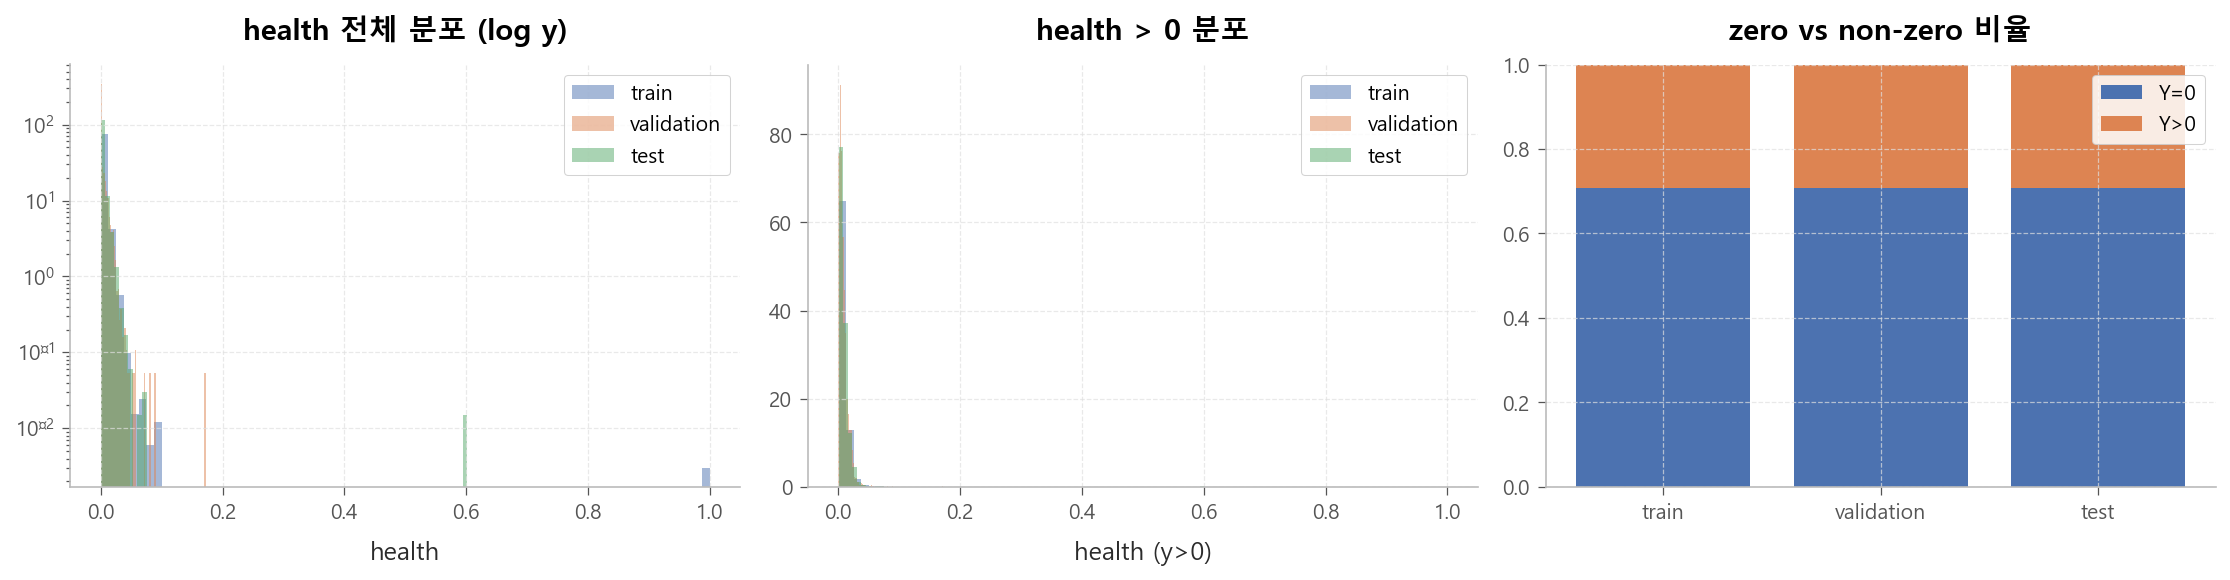

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) 전체 히스토그램 (log scale)
ax = axes[0]
for s in splits:
    y = ys[s][TARGET_COL]
    ax.hist(y, bins=80, alpha=0.5, label=s, density=True)
ax.set_yscale("log")
ax.set_title("health 전체 분포 (log y)")
ax.set_xlabel("health")
ax.legend()

# (b) Y > 0 만 히스토그램
ax = axes[1]
for s in splits:
    y = ys[s][TARGET_COL]
    y_pos = y[y > 0]
    ax.hist(y_pos, bins=80, alpha=0.5, label=s, density=True)
ax.set_title("health > 0 분포")
ax.set_xlabel("health (y>0)")
ax.legend()

# (c) zero vs non-zero 비율
ax = axes[2]
zero_ratios = [(ys[s][TARGET_COL] == 0).mean() for s in splits]
pos_ratios = [1 - r for r in zero_ratios]
x = np.arange(len(splits))
ax.bar(x, zero_ratios, label="Y=0", color="#4C72B0")
ax.bar(x, pos_ratios, bottom=zero_ratios, label="Y>0", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylim(0, 1)
ax.set_title("zero vs non-zero 비율")
ax.legend()

plt.tight_layout()
plt.show()

## 4. 분포 일치성 통계 검정 (KS test)

두 split의 `health` 분포가 동일한지 Kolmogorov-Smirnov test로 확인. p-value가 크면 (> 0.05) 같은 분포라고 볼 수 있음.

In [6]:
from scipy.stats import ks_2samp

pairs = [("train", "validation"), ("train", "test"), ("validation", "test")]
rows = []
for a, b in pairs:
    ya = ys[a][TARGET_COL].values
    yb = ys[b][TARGET_COL].values
    stat, pval = ks_2samp(ya, yb)
    rows.append({"pair": f"{a} vs {b}", "ks_stat": stat, "p_value": pval})

pd.DataFrame(rows)

,pair,ks_stat,p_value
0,train vs validation,0.006591,0.936203
1,train vs test,0.008496,0.727333
2,validation vs test,0.006401,0.993940


---

## 5. 결측치 / 이상치 × health 관계 분석

가설: **health 극단값 unit의 die들은, 일반 unit의 die들보다 결측/이상치 개수가 많을 것이다.**

노트북 `3_modeling/e2e_twostage.ipynb` 의 전처리 설정과 동일:
- **이상치**: `winsorize`, `upper_pct=0.995` → train 기준 각 feature 상위 0.5% 초과 = 이상치 (clip 대상)
- **결측치**: `missing_threshold=0.25`, `imputation_method='spatial'` → 25% 초과 컬럼은 제거 후 spatial imputation

결측은 imputation **전** 원본에서, 이상치는 cleaning **후** (imputed) 데이터에서 계산한다.

### 5.1 원본 로드 + raw 결측 카운트 (die 단위)

In [7]:
from utils.data import load_all, get_feat_cols, split_xs
from utils.config import KEY_COL, POSITION_COL, SPLIT_COL, PROJECT_ROOT

xs, ys_dict = load_all()
feat_cols_all = get_feat_cols(xs)
xs_dict = split_xs(xs)
print(f'전체 feature 수: {len(feat_cols_all)}')

# die별 raw 결측 개수 (1,087개 전체 기준)
raw_missing_all = xs[feat_cols_all].isna().sum(axis=1)
print(f'raw 결측 per die (1087): mean={raw_missing_all.mean():.2f}, max={raw_missing_all.max()}')

Xs: (174980, 1091)  |  Ys: train=26,247, val=8,749, test=8,749
전체 feature 수: 1087
raw 결측 per die (1087): mean=18.48, max=1087


### 5.2 Cleaning 실행 (e2e 노트북과 동일 파라미터)

`clean_cols` 를 얻기 위한 목적. spatial imputation까지 포함.

In [8]:
sys.path.insert(0, os.path.join(PROJECT_ROOT, '2_preprocessing'))
from cleaning import run_cleaning

cleaning_params = dict(
    const_threshold=1e-6,
    missing_threshold=0.25,
    remove_duplicates=True,
    corr_threshold=0.95,
    add_indicator=False,   # 분석용이므로 indicator 컬럼은 생성 안 함
    imputation_method='spatial',
    spatial_max_dist=2.0,
)

xs_train_c, xs_val_c, xs_test_c, clean_cols, clean_report = run_cleaning(
    xs, feat_cols_all, xs_dict, **cleaning_params,
)

# indicator 컬럼이 섞여있으면 제외 (add_indicator=False라 없어야 하지만 안전)
clean_cols = [c for c in clean_cols if not c.endswith('_isna')]
print(f'clean_cols: {len(clean_cols)}개')

클리닝 파이프라인 시작
원본 feature 수: 1087
[상수/극저분산 제거] threshold=1e-06
  제거: 105개, 잔여: 982개
    컬럼: 1087 → 982 (105개 제거)
    DataFrame: (104988, 986)

[고결측 제거] threshold=25%
  제거: 10개, 잔여: 972개
    컬럼: 982 → 972 (10개 제거)
    DataFrame: (104988, 976)

[중복 컬럼 제거] sample_n=5000
  제거: 26개, 잔여: 946개
    컬럼: 972 → 946 (26개 제거)
    DataFrame: (104988, 950)

[고상관 제거] threshold=0.95, keep_by=std (std)
  제거: 211개, 잔여: 735개
    컬럼: 946 → 735 (211개 제거)
    DataFrame: (104988, 739)

[공간 보간 imputation] 총 결측: 465,920
  1단계 (공간 보간, dist<=2.0): 99,896개 채움 → 잔여: 366,024
  2단계 (lot 평균): 366,024개 채움 → 잔여: 0

  [요약] 465,920 → 공간(99,896) → lot(366,024) → 전체(0) → 잔여(0)

클리닝 완료: 1087 → 735 features (352개 제거)
  train: (104988, 739)
  val:   (34996, 739)
  test:  (34996, 739)
clean_cols: 735개


### 5.3 train 기준 99.5 분위 임계값 → die별 이상치 개수

In [9]:
# train 기준 임계값 (노트북과 동일: lower=0.0, upper=0.995)
upper_thr = xs_train_c[clean_cols].quantile(0.995)
print(f'임계값 계산 완료: {len(upper_thr)}개 feature')

def count_outliers(df, cols, thr):
    # thr 초과면 이상치 (= clip 대상)
    return (df[cols] > thr).sum(axis=1)

n_out_train = count_outliers(xs_train_c, clean_cols, upper_thr)
n_out_val   = count_outliers(xs_val_c,   clean_cols, upper_thr)
n_out_test  = count_outliers(xs_test_c,  clean_cols, upper_thr)

print(f'die당 이상치 수:')
print(f'  train: mean={n_out_train.mean():.2f}, max={n_out_train.max()}')
print(f'  val:   mean={n_out_val.mean():.2f}, max={n_out_val.max()}')
print(f'  test:  mean={n_out_test.mean():.2f}, max={n_out_test.max()}')

임계값 계산 완료: 735개 feature
die당 이상치 수:
  train: mean=2.02, max=202
  val:   mean=2.06, max=201
  test:  mean=2.03, max=217


### 5.4 die-level 분석 DataFrame 생성

각 die의 [split, ufs_serial, position, health, n_missing_raw1087, n_missing_clean, n_outlier] 테이블.

In [10]:
# raw 결측: 1,087 전체 & clean_cols 기준 두 가지 모두
raw_missing_clean = xs[clean_cols].isna().sum(axis=1)

die_df = xs[[KEY_COL, POSITION_COL, SPLIT_COL]].copy()
die_df['n_missing_raw1087'] = raw_missing_all.values
die_df['n_missing_clean']   = raw_missing_clean.values

# 이상치는 split별 원본 index 기준으로 붙임
out_series = pd.concat([
    pd.Series(n_out_train.values, index=xs_train_c.index),
    pd.Series(n_out_val.values,   index=xs_val_c.index),
    pd.Series(n_out_test.values,  index=xs_test_c.index),
]).sort_index()
die_df['n_outlier'] = out_series.reindex(die_df.index).values

# health merge (split별)
ys_all = pd.concat([
    ys_dict['train'].assign(**{SPLIT_COL: 'train'}),
    ys_dict['validation'].assign(**{SPLIT_COL: 'validation'}),
    ys_dict['test'].assign(**{SPLIT_COL: 'test'}),
], ignore_index=True)
die_df = die_df.merge(ys_all, on=[KEY_COL, SPLIT_COL], how='left')

print(f'die_df shape: {die_df.shape}')
die_df.head()

die_df shape: (174980, 7)


,ufs_serial,position,split,n_missing_raw1087,n_missing_clean,n_outlier,health
0,S00000,1,train,16,0,0,0.0
1,S00001,1,test,14,0,0,0.0
2,S00002,1,train,16,0,0,0.0
3,S00003,1,train,16,0,0,0.0
4,S00004,1,train,19,5,0,0.0


### 5.5 unit 레벨 집계 (한 unit = 4 dies)

unit당 4개 die의 `n_missing` / `n_outlier` 를 **합(sum)** 으로 집계. health 는 unit당 1개.

In [11]:
agg_cols = ['n_missing_raw1087', 'n_missing_clean', 'n_outlier']
unit_df = (
    die_df.groupby([KEY_COL, SPLIT_COL, TARGET_COL], as_index=False)[agg_cols]
    .sum()
)
print(f'unit_df shape: {unit_df.shape}')
print(f'split별 unit 수: {unit_df[SPLIT_COL].value_counts().to_dict()}')
unit_df.head()

unit_df shape: (43745, 6)
split별 unit 수: {'train': 26247, 'test': 8749, 'validation': 8749}


,ufs_serial,split,health,n_missing_raw1087,n_missing_clean,n_outlier
0,S00000,train,0.0,64,0,12
1,S00001,test,0.0,70,14,13
2,S00002,train,0.0,66,0,0
3,S00003,train,0.0,64,0,2
4,S00004,train,0.0,75,17,3


### 5.6 y 구간별 비교

| bin | 조건 |
|---|---|
| `zero` | y = 0 |
| `low` | 0 < y ≤ median(y>0) |
| `mid` | median(y>0) < y ≤ Q99(y>0) |
| `high` | Q99(y>0) < y ≤ Q999(y>0) |
| `extreme` | y > Q999(y>0) (상위 0.1%) |

bin 기준값(median, Q99, Q999)은 **train의 y>0**에서 계산해서 모든 split에 동일 적용.

In [12]:
# train y>0 기준으로 bin 경계 고정
y_train_pos = unit_df.loc[(unit_df[SPLIT_COL] == 'train') & (unit_df[TARGET_COL] > 0), TARGET_COL]
BIN_MED  = y_train_pos.median()
BIN_Q99  = y_train_pos.quantile(0.99)
BIN_Q999 = y_train_pos.quantile(0.999)
print(f'bin 경계 (train y>0): median={BIN_MED:.5f}, Q99={BIN_Q99:.5f}, Q999={BIN_Q999:.5f}')

def to_bin(v):
    if v == 0: return 'zero'
    if v <= BIN_MED:  return 'low'
    if v <= BIN_Q99:  return 'mid'
    if v <= BIN_Q999: return 'high'
    return 'extreme'

unit_df['y_bin'] = unit_df[TARGET_COL].apply(to_bin)
bin_order = ['zero', 'low', 'mid', 'high', 'extreme']

summary_rows = []
for split_name in ['train', 'validation', 'test']:
    sub = unit_df[unit_df[SPLIT_COL] == split_name]
    for b in bin_order:
        g = sub[sub['y_bin'] == b]
        if len(g) == 0:
            continue
        summary_rows.append({
            'split': split_name,
            'y_bin': b,
            'n_units': len(g),
            'y_mean': g[TARGET_COL].mean(),
            'miss1087_mean': g['n_missing_raw1087'].mean(),
            'miss_clean_mean': g['n_missing_clean'].mean(),
            'outlier_mean': g['n_outlier'].mean(),
            'outlier_median': g['n_outlier'].median(),
            'outlier_max': g['n_outlier'].max(),
        })

summary = pd.DataFrame(summary_rows)
summary.round(3)

bin 경계 (train y>0): median=0.00648, Q99=0.03346, Q999=0.07211


,split,y_bin,n_units,y_mean,miss1087_mean,miss_clean_mean,outlier_mean,outlier_median,outlier_max
0,train,zero,18583,0.000,73.925,10.760,8.119,5.0,205
1,train,low,3832,0.003,74.437,10.869,7.834,5.0,93
2,train,mid,3755,0.013,72.242,9.361,8.274,5.0,193
3,train,high,69,0.043,63.710,3.783,6.507,5.0,22
4,train,extreme,8,0.199,60.375,2.125,7.000,4.0,20
5,validation,zero,6194,0.000,75.170,11.542,8.132,5.0,197
6,validation,low,1272,0.004,70.116,7.829,8.297,5.0,198
7,validation,mid,1260,0.013,76.802,12.404,8.821,6.0,208
8,validation,high,20,0.044,63.350,3.650,8.100,4.0,31
9,validation,extreme,3,0.114,61.333,0.333,3.333,3.0,6


### 5.7 시각화 (train 기준)

C:\Users\COM\AppData\Local\Temp\ipykernel_23448\3092272055.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=available_bins, showfliers=True)
C:\Users\COM\AppData\Local\Temp\ipykernel_23448\3092272055.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=available_bins, showfliers=True)
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph 

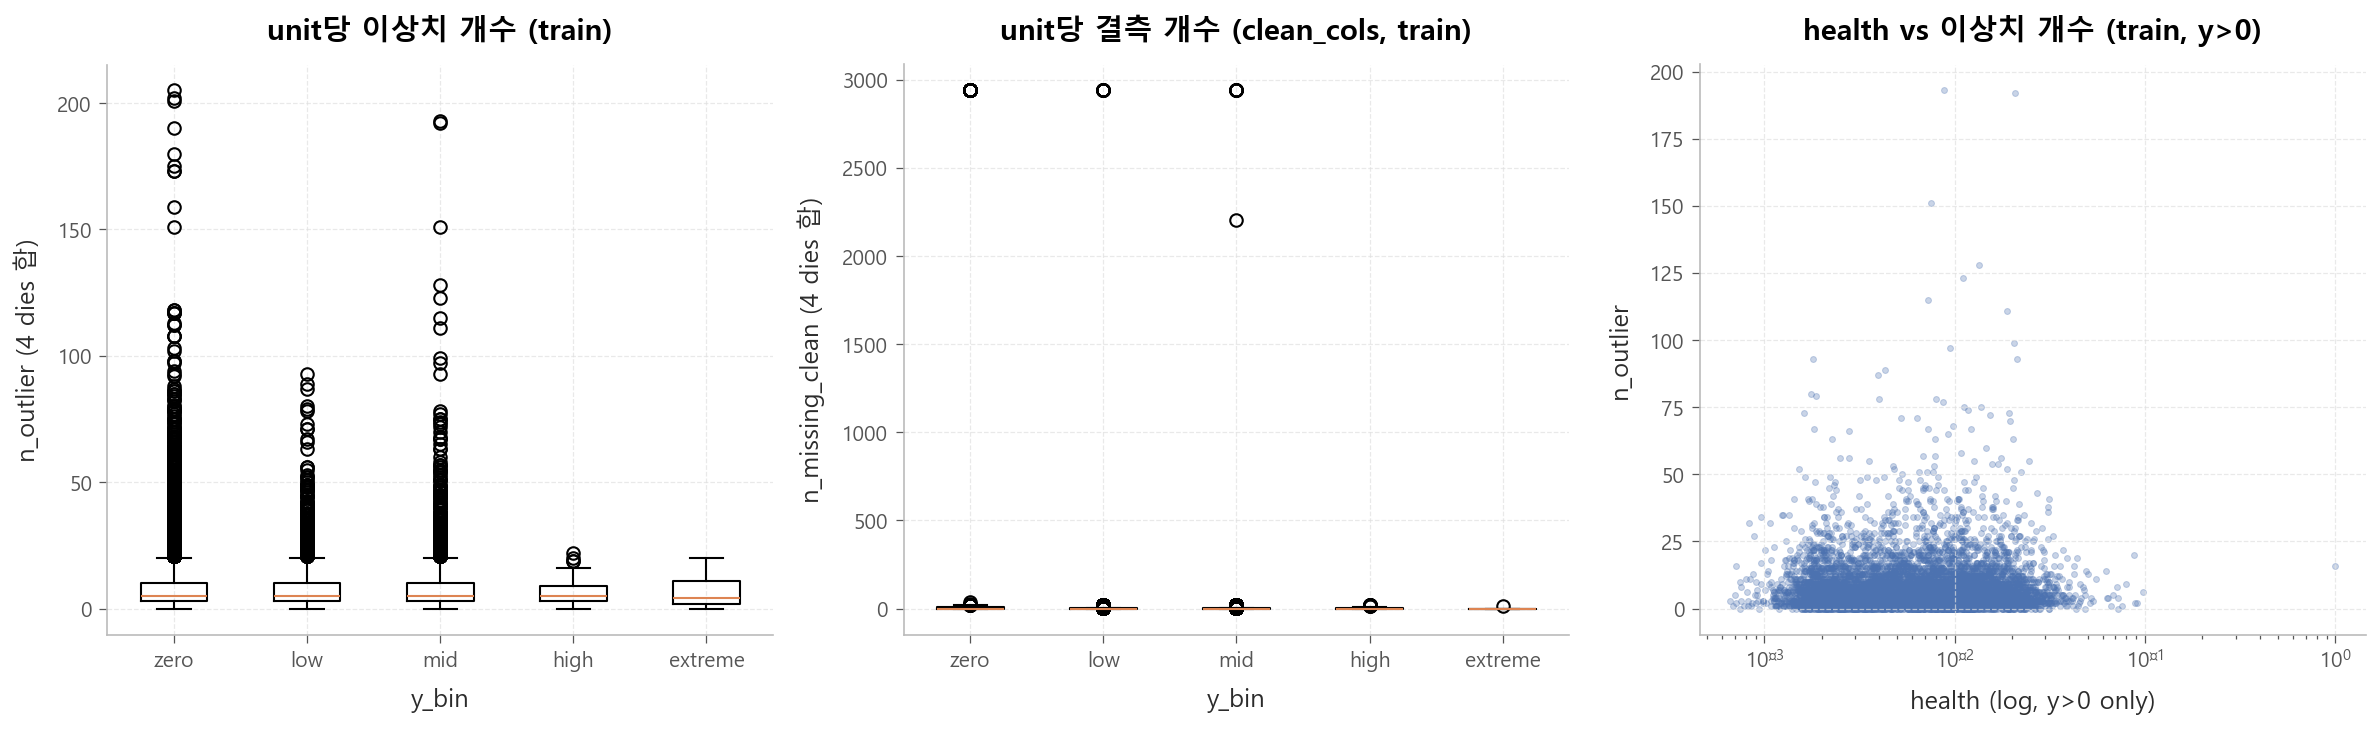

In [13]:
train_binned = unit_df[unit_df[SPLIT_COL] == 'train']
available_bins = [b for b in bin_order if b in train_binned['y_bin'].unique()]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) y_bin 별 이상치 개수 boxplot
ax = axes[0]
data = [train_binned.loc[train_binned['y_bin'] == b, 'n_outlier'].values for b in available_bins]
ax.boxplot(data, labels=available_bins, showfliers=True)
ax.set_title('unit당 이상치 개수 (train)')
ax.set_xlabel('y_bin')
ax.set_ylabel('n_outlier (4 dies 합)')

# (b) y_bin 별 결측 개수 boxplot (clean_cols 기준)
ax = axes[1]
data = [train_binned.loc[train_binned['y_bin'] == b, 'n_missing_clean'].values for b in available_bins]
ax.boxplot(data, labels=available_bins, showfliers=True)
ax.set_title('unit당 결측 개수 (clean_cols, train)')
ax.set_xlabel('y_bin')
ax.set_ylabel('n_missing_clean (4 dies 합)')

# (c) y vs n_outlier scatter (log x)
ax = axes[2]
pos = train_binned[train_binned[TARGET_COL] > 0]
ax.scatter(pos[TARGET_COL], pos['n_outlier'], alpha=0.3, s=8)
ax.set_xscale('log')
ax.set_xlabel('health (log, y>0 only)')
ax.set_ylabel('n_outlier')
ax.set_title('health vs 이상치 개수 (train, y>0)')

plt.tight_layout()
plt.show()

### 5.8 극단값 unit 상세 (train top 20)

In [14]:
top20 = (
    unit_df[unit_df[SPLIT_COL] == 'train']
    .sort_values(TARGET_COL, ascending=False)
    .head(20)
)
top20[[KEY_COL, TARGET_COL, 'n_missing_raw1087', 'n_missing_clean', 'n_outlier']].round(4)

,ufs_serial,health,n_missing_raw1087,n_missing_clean,n_outlier
39390,S39398,1.0000,58,0,16
17866,S17874,0.0974,56,0,6
17553,S17561,0.0912,54,0,2
31946,S31954,0.0882,56,0,2
17822,S17830,0.0881,64,0,20
17639,S17647,0.0798,79,17,9
35424,S35432,0.0759,60,0,1
17841,S17849,0.0721,56,0,0
17302,S17310,0.0721,76,20,4
27275,S27283,0.0713,64,0,8
